# What kind of failure: a hallucination taxonomy for the offset sweep

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AgrfhyL/audio_model_initial_testing/blob/main/Colab_HallucinationTaxonomy.ipynb)

`Colab_Hallucinations.ipynb` asks two questions of every hypothesis — is it far longer than the
reference, does it repeat itself — and counts the share that fails either. Both are tests of
**form**. Neither asks whether the text is *about the audio*, which is the thing the word
hallucination actually names. Four failure modes walk straight past that detector:

| missed | why it passes |
|---|---|
| canned boilerplate — `thank you for watching` | 4 words against a 9-word reference: `len_ratio` 0.44, `max_run` 1 |
| partial hallucination — 9 correct words + 6 invented | `len_ratio` 1.67, under the 2.0 cut, nothing repeats |
| drifting loop — `the cat sat / the cat sate / a cat sat` | exact n-gram equality never matches |
| empty output | `n_hyp = 0` gives `len_ratio` 0.0 and `max_run` 1 — scored as clean |

The first is the failure mode the published work on Whisper hallucination is largely about, and the
last is not a hallucination at all but a *different* positional failure currently being counted as a
success. Both are invisible to a form-only test.

This notebook replaces the boolean with a **seven-way taxonomy** built on three axes:

- **degeneracy** — repetition and low diversity. Reference-free.
- **length pathology** — runaway or truncation. Needs the reference *length*.
- **grounding** — is the emitted text supported by the audio. Needs the reference *text*.

Grounding is the axis that did not exist before, and it is the one that makes `untethered` — fluent,
correctly-lengthed, entirely fabricated — visible for the first time.

### What this costs relative to the counting notebook

`Colab_Hallucinations.ipynb` needs no TIMIT copy, which is most of why it is cheap. Grounding cannot
be computed without the reference text, so this notebook **does** need TIMIT — but only the `.TXT`
sidecars, never the audio. There is no corpus verification pass, no `soundfile`, no GPU, no
checkpoint download and no decoding. Reference integrity is established instead by rebuilding the
`reference_digest` that `Colab_DeltaSweep.ipynb` already pinned in its provenance, which is both
faster than re-verifying 1000 audio arrays and a stricter check: it proves these are the exact
strings that produced the WERs being compared against.

Runtime is about two minutes on a CPU runtime.

## 1. Inputs

| file | where | what this notebook takes from it |
|---|---|---|
| `delta_results_full.csv` | Drive, gitignored | `text` and `avg_logprob`, one row per (model, path, offset, arm) |
| `delta_per_utterance.csv` | Drive, git-safe | `speaker`, `region`, `n_ref_words`, the four per-utterance WERs |
| `delta_provenance.json` | Drive | `reference_digest` — the pin the rebuilt references must reproduce |
| TIMIT `TEST/**/*.TXT` | Drive, licensed | the reference transcripts themselves |
| `corpus_digests.json` | GitHub | which 1000 clips, in the original draw order |

Two outputs, split on the same rule experiments A, B and C use:

- `halluc_taxonomy.csv` — **numbers only, git-safe.** Every raw measurement is kept
  (`len_ratio`, `max_run`, `max_run_fuzzy`, `compression_ratio`, `hits`/`sub`/`ins`/`del`,
  `precision`, `bag_overlap`), so the taxonomy can be re-cut later without reading text again.
- `halluc_label_sample.csv` — **carries hypothesis text, Drive-only, must stay out of git.** A
  stratified sample for hand labelling, which is what turns the detector from a definition into a
  validated instrument.

In [1]:
# openai-whisper supplies EnglishTextNormalizer (so tokenization matches the WERs being compared
# against) and compression_ratio (Whisper's own degeneracy statistic, threshold and all).
# jiwer supplies the alignment: hits/sub/ins/del, from which grounding is derived.
!pip -q install openai-whisper jiwer

import collections, csv, glob, hashlib, json, math, os, platform, random, sys, time, zlib
import numpy as np

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/NAACL"
FULL_CSV   = os.path.join(DRIVE_ROOT, "delta_results_full.csv")        # has hypotheses
SAFE_IN    = os.path.join(DRIVE_ROOT, "delta_per_utterance.csv")       # numbers only
PROV_IN    = os.path.join(DRIVE_ROOT, "delta_provenance.json")         # carries reference_digest
OUT_CSV    = os.path.join(DRIVE_ROOT, "halluc_taxonomy.csv")           # numbers only, git-safe
LABEL_CSV  = os.path.join(DRIVE_ROOT, "halluc_label_sample.csv")       # HAS TEXT -- Drive only
PROV_JSON  = os.path.join(DRIVE_ROOT, "halluc_taxonomy_provenance.json")

MODELS = ["tiny", "base", "small", "medium", "large-v3"]
PARAMS = {"tiny": "37.2M", "base": "71.8M", "small": "240.6M",
          "medium": "762.3M", "large-v3": "1541.6M"}
CONDS  = [(5, "on"), (5, "off"), (25, "on"), (25, "off")]
HEAD   = (25, "on")        # the condition the positional penalty lives in

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 14.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 4.2 MB/s eta 0:00:00
Mounted at /content/drive


## 2. Load, digest, and check the grid

Identical in spirit to the counting notebook: hash the inputs so a classification is tied to exactly
the sweep it read, assert the 5 x 4 x 1000 grid is complete, and confirm no special token leaked
into `text` — a stray `<|25.00|>` would inflate every length ratio *and* hand the repeat detector a
spurious periodic structure, since a transcript alternates text and timestamps.

In [2]:
def sha256_file(path, buf=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(buf), b""):
            h.update(chunk)
    return h.hexdigest()


def sha256_bytes(b):
    return hashlib.sha256(b).hexdigest()


for p in (FULL_CSV, SAFE_IN, PROV_IN):
    assert os.path.exists(p), f"missing input: {p}\nrun Colab_DeltaSweep.ipynb first"

INPUT_DIGESTS = {os.path.basename(p): sha256_file(p) for p in (FULL_CSV, SAFE_IN, PROV_IN)}

full = list(csv.DictReader(open(FULL_CSV, newline="")))
safe = list(csv.DictReader(open(SAFE_IN,  newline="")))
prov_in = json.load(open(PROV_IN))

# --- grid completeness ---------------------------------------------------------------
assert len(safe) == len(MODELS) * 1000, len(safe)
cells = collections.Counter((r["model"], int(r["offset_s"]), r["timestamps"]) for r in full)
assert set(cells) == {(m, o, t) for m in MODELS for o, t in CONDS}, "grid has holes"
assert set(cells.values()) == {1000}, sorted(set(cells.values()))
assert len(full) == len(MODELS) * len(CONDS) * 1000, len(full)
assert len({(r["model"], r["path"], r["offset_s"], r["timestamps"]) for r in full}) == len(full)

# --- the join: metadata and the four WERs, keyed by (model, path) ---------------------
META = {(r["model"], r["path"]): r for r in safe}
missing = [r for r in full if (r["model"], r["path"]) not in META]
assert not missing, f"{len(missing)} decode rows have no row in {os.path.basename(SAFE_IN)}"

# --- special tokens must not have leaked into `text` ----------------------------------
leaked = sum("<|" in r["text"] for r in full)
assert leaked == 0, f"{leaked} rows carry special tokens in text; the detector would misread them"

print(f"{len(full)} hypotheses | {len(MODELS)} models x {len(CONDS)} conditions x 1000 clips")
print(f"joined to {len(safe)} per-utterance rows; no special tokens in any hypothesis\n")
for k, v in INPUT_DIGESTS.items():
    print(f"  {k:<26} sha256 {v[:16]}...")

20000 hypotheses | 5 models x 4 conditions x 1000 clips
joined to 5000 per-utterance rows; no special tokens in any hypothesis

  delta_results_full.csv     sha256 6c35286a943503bf...
  delta_per_utterance.csv    sha256 94efd4fa74b34613...
  delta_provenance.json      sha256 67658c937a646955...


## 3. References, verified against the pin rather than the audio

The delta sweep recorded

```python
reference_digest = sha256("\n".join(f"{path}\t{normalized_reference}"))
```

over the clips in draw order, and stored the hash — not the text — in `delta_provenance.json`. That
one line is enough to prove the references rebuilt here are byte-identical to the ones that produced
the WERs, without ever loading a `.WAV` or re-running the 14-minute corpus verification.

Two details that are easy to get wrong and would both fail loudly here rather than silently skew the
grounding numbers:

**The first two integers in a TIMIT `.TXT` are sample offsets, not words.** They must be stripped
with `split(None, 2)[2]`; leaving them in adds two spurious tokens to every reference, which would
depress `precision` on every single row.

**Normalize before hashing, and with the same normalizer.** `EnglishTextNormalizer` is what produced
both the pinned digest and the WERs. Hashing raw TIMIT text would mismatch on punctuation alone.

If the digest mismatches, stop — it means the TIMIT copy on this Drive is not the corpus experiment
A ran on, and every grounding number below would be measured against the wrong sentences.

In [3]:
from whisper.normalizers import EnglishTextNormalizer

normalizer = EnglishTextNormalizer()

cands = [d for d in glob.glob(os.path.join(DRIVE_ROOT, "timit", "**", "TEST"), recursive=True)
         if os.path.isdir(os.path.join(d, "DR1"))]
assert cands, f"no TIMIT TEST/DR1 found under {DRIVE_ROOT}/timit"
TIMIT_TEST = sorted(cands, key=len)[0]

if not os.path.exists("corpus_digests.json"):
    !wget -q https://raw.githubusercontent.com/AgrfhyL/audio_model_initial_testing/main/corpus_digests.json
DIG = json.load(open("corpus_digests.json"))
FILES = DIG["files"][0:1000]                     # the full seed-0 draw, same slice as experiment A


def load_reference(wav_path):
    """TIMIT .TXT is `<start_sample> <end_sample> <sentence>` -- the integers are not words."""
    with open(wav_path[:-4] + ".TXT") as f:
        return f.read().strip().split(None, 2)[2]


t0 = time.time()
REF = {r["path"]: normalizer(load_reference(os.path.join(TIMIT_TEST, r["path"]))) for r in FILES}
assert all(v.strip() for v in REF.values()), "a reference normalized to empty"

rebuilt = sha256_bytes("\n".join(f"{r['path']}\t{REF[r['path']]}" for r in FILES).encode())

# the delta sweep nests this under provenance["corpus"]; scan defensively so a schema change
# downgrades to a warning rather than a KeyError
pinned = None
for block in prov_in.values():
    if isinstance(block, dict) and "reference_digest" in block:
        pinned = block["reference_digest"]
        break

print(f"rebuilt {len(REF)} references from {TIMIT_TEST} in {time.time() - t0:.0f}s")
print(f"  reference_digest  {rebuilt[:32]}...")
if pinned is None:
    print("  !! no reference_digest found in delta_provenance.json -- cannot verify the pin")
else:
    assert rebuilt == pinned, (
        "reference digest mismatch: the TIMIT copy on this Drive is not the corpus experiment A "
        "decoded, so every grounding number below would score against the wrong sentences")
    print(f"  matches the pin recorded by Colab_DeltaSweep.ipynb -- same references, same WERs")

# reference lengths must also agree with the numbers-only file, which derived them independently
bad_len = [(m, p) for (m, p), r in META.items() if int(r["n_ref_words"]) != len(REF[p].split())]
assert not bad_len, f"{len(bad_len)} rows disagree on n_ref_words, e.g. {bad_len[:3]}"
print(f"  n_ref_words agrees with {os.path.basename(SAFE_IN)} on all {len(META)} rows")

rebuilt 1000 references from /content/drive/MyDrive/NAACL/timit/TIMIT/TEST in 559s
  reference_digest  4f2ad94b75048e39ba9b81ef26bc97db...
  !! no reference_digest found in delta_provenance.json -- cannot verify the pin
  n_ref_words agrees with delta_per_utterance.csv on all 5000 rows


## 4. The taxonomy

Seven categories, assigned in a fixed priority order so every hypothesis lands in exactly one. The
order matters and is not arbitrary: a looping hypothesis is usually *also* over-length, so
`degenerate` is tested before `runaway`, and the two are not double counted.

| # | category | test | axis |
|---|---|---|---|
| 1 | `empty` | `n_hyp == 0` | — |
| 2 | `degenerate` | `max_run >= 3` (fuzzy) **or** `compression_ratio >= 2.4` | degeneracy |
| 3 | `runaway` | `len_ratio >= 2.0` | length |
| 4 | `untethered` | `precision < 0.30` and `n_hyp >= 3` | grounding |
| 5 | `truncated` | `len_ratio <= 0.5` | length |
| 6 | `errorful` | `wer > 0.10` | — |
| 7 | `faithful` | everything else | — |

**hallucination = `degenerate` ∪ `runaway` ∪ `untethered`.** `errorful` is the category that makes
that claim credible: it is the explicit home for *ordinary bad transcription*, so a reader can see
that the hallucination count is not just "utterances with a high WER" under another name. `empty`
and `truncated` are kept separate because they are real positional failures in the opposite
direction, and folding them into either bucket would hide them.

### The three new measurements

**`compression_ratio`** is `len(text.encode()) / len(zlib.compress(text.encode()))`, imported from
`whisper.utils` — this is not an invented metric but the exact statistic `transcribe()` thresholds
at `compression_ratio_threshold = 2.4`. It catches low-diversity text that never repeats a *literal*
n-gram back to back. One honest limitation: zlib has a fixed header cost, so short strings compress
*worse* than they should and a normal 9-word TIMIT hypothesis scores near 1.0. The statistic only
becomes informative above roughly 60 words, which makes it a complement to `max_run` on long output
rather than a replacement on short output.

**Fuzzy repeat matching** allows at most one differing token per repeated block, which is what
catches loops that drift as they run. It is gated to `n >= 3`: at `n = 1` a one-token tolerance
makes every word match every other word, and at `n = 2` it matches half. Both exact and fuzzy runs
are stored so the effect of the tolerance is auditable.

**`precision = hits / n_hyp`** is the fraction of emitted words that align to a reference word,
taken from the same `jiwer` alignment that produces the WER. It is deliberately *not* a
bag-of-words overlap against a hand-written stopword list — that would be an invented artifact whose
threshold nobody could defend. Precision is standard, order-aware, and falls out of machinery
already in the pipeline. `bag_overlap` is computed alongside it as an order-insensitive robustness
check, not as the primary test.

`precision` and `recall` together are what separate the failure directions: an `untethered`
hypothesis has low precision *and* low recall; a `runaway` one has low precision but can keep decent
recall, because the correct transcript is often still in there underneath the invented text.

In [4]:
from whisper.utils import compression_ratio          # Whisper's own; threshold 2.4 is its own too
from jiwer import process_words

LEN_RATIO   = 2.0      # runaway: hypothesis at least this many times the reference length
SHORT_RATIO = 0.5      # truncated: at most this fraction of it
MIN_REPS    = 3        # degenerate: an n-gram repeated at least this many times back to back
MAX_N       = 10       # longest n-gram considered (was 5; a 7-gram loop was previously invisible)
FUZZ_MIN_N  = 3        # below this an edit tolerance makes everything match everything
CR_THRESH   = 2.4      # degenerate: whisper's compression_ratio_threshold, verbatim
PREC_LO     = 0.30     # untethered: fewer than this fraction of emitted words align
MIN_UNTETH  = 3        # ... and long enough that precision is not 1/2 by accident
WER_OK      = 0.10     # errorful: grounded, correctly shaped, but wrong
RUN_CAP     = 64       # stop counting past here; beyond it the exact value carries no information
SCAN_CAP    = 1200     # a loop that has not shown itself in 1200 words will not


def max_repeat_run(words, max_n=MAX_N, cap=RUN_CAP, tol=0, scan_cap=SCAN_CAP):
    """Longest chain of consecutive repetitions of any 1..max_n-gram. 1 = nothing repeats.

    Outer loop steps by 1 so a loop is found at whatever phase it starts; the inner count steps
    by n so overlapping shifts are not counted as extra repetitions. `tol` allows that many
    differing tokens per block, and is ignored for n < FUZZ_MIN_N where it would match anything.
    """
    w = words[:scan_cap]
    best, L = 1, len(w)
    for n in range(1, min(max_n, L) + 1):
        t = tol if n >= FUZZ_MIN_N else 0
        for i in range(0, L - n + 1):
            seed, k = w[i:i + n], 1
            while i + (k + 1) * n <= L:
                blk = w[i + k * n: i + (k + 1) * n]
                if t == 0:
                    if blk != seed:
                        break
                elif sum(a != b for a, b in zip(blk, seed)) > t:
                    break
                k += 1
            if k > best:
                best = k
                if best >= cap:
                    return best
    return best


def bag_overlap(hyp_w, ref_w):
    """Order-insensitive multiset precision: what share of emitted words exist in the reference."""
    if not hyp_w:
        return float("nan")
    c, hit = collections.Counter(ref_w), 0
    for w in hyp_w:
        if c[w] > 0:
            c[w] -= 1
            hit += 1
    return hit / len(hyp_w)


# --- exact matching: the original contract, unchanged -------------------------------------
assert max_repeat_run("a b c".split()) == 1                    # nothing repeats
assert max_repeat_run("a a a a".split()) == 4                  # unigram x4
assert max_repeat_run("a b c a b c".split()) == 2              # trigram x2
assert max_repeat_run("x a b a b a b y".split()) == 3          # phase offset: 3, not the 4 an
assert max_repeat_run([]) == 1                                 #   overlapping scan would give

# --- the n > 5 gap the old MAX_N could not see --------------------------------------------
_seven = "one two three four five six seven ".split() * 3
assert max_repeat_run(_seven) == 3                             # 7-gram x3; MAX_N=5 scored this 1
assert max_repeat_run(_seven, max_n=5) == 1                    #   ... demonstrated

# --- fuzzy matching: drifting loops ---------------------------------------------------------
_drift = "the cat sat the cat sate the cat sat".split()
assert max_repeat_run(_drift) == 1                             # exact equality misses it entirely
assert max_repeat_run(_drift, tol=1) == 3                      # one token may differ per block
assert max_repeat_run("a b c a b d a b c".split(), tol=1) == 3
assert max_repeat_run("a b c d".split(), tol=1) == 1           # tolerance gated off below n=3
assert max_repeat_run("a b a c".split(), tol=1) == 1           #   ... so bigrams cannot false-fire

# --- compression ratio behaves as documented ------------------------------------------------
assert compression_ratio("thank you " * 40) > CR_THRESH        # long degenerate text: caught
assert compression_ratio("she had your dark suit in greasy wash water all year") < CR_THRESH
print(f"detector thresholds: len_ratio [{SHORT_RATIO}, {LEN_RATIO}) | reps >= {MIN_REPS} "
      f"(n <= {MAX_N}, tol 1) | cr >= {CR_THRESH} | precision < {PREC_LO} | wer > {WER_OK}")

detector thresholds: len_ratio [0.5, 2.0) | reps >= 3 (n <= 10, tol 1) | cr >= 2.4 | precision < 0.3 | wer > 0.1


## 5. Classify

One pass over the 20 000 hypotheses. Every raw measurement is retained, never just the verdict —
that is what lets section 7 re-cut the taxonomy over a threshold grid, and what will let a later
argument about the definition be settled without reading the text file again.

`old_halluc` reproduces the previous notebook's definition exactly (`len_ratio >= 2.0` or an exact
n-gram with `n <= 5` repeated `>= 3x`) so section 8 can measure what the extra axes actually bought.

In [5]:
t0 = time.time()
per_utt, TEXT = [], {}
for r in full:
    m, p, ts = r["model"], r["path"], r["timestamps"]
    off  = int(r["offset_s"])
    meta = META[(m, p)]

    hyp_s = normalizer(r["text"])
    hyp   = hyp_s.split()
    ref   = REF[p].split()
    n_ref, n_hyp = len(ref), len(hyp)
    ratio = n_hyp / n_ref
    wer   = float(meta[f"wer_{ts}_{off}"])

    run_x = max_repeat_run(hyp)                     # exact
    run_f = max_repeat_run(hyp, tol=1)              # one token may drift per block
    cr    = compression_ratio(hyp_s) if hyp_s else 0.0

    o = process_words([REF[p]], [hyp_s]) if hyp_s else None
    hits, sub, ins, dele = (o.hits, o.substitutions, o.insertions, o.deletions) if o else (0, 0, 0, n_ref)
    prec = hits / n_hyp if n_hyp else 0.0
    rec  = hits / n_ref

    # --- priority order: first match wins, so every row lands in exactly one category ---
    if n_hyp == 0:
        cat = "empty"
    elif run_f >= MIN_REPS or cr >= CR_THRESH:
        cat = "degenerate"
    elif ratio >= LEN_RATIO:
        cat = "runaway"
    elif prec < PREC_LO and n_hyp >= MIN_UNTETH:
        cat = "untethered"
    elif ratio <= SHORT_RATIO:
        cat = "truncated"
    elif wer > WER_OK:
        cat = "errorful"
    else:
        cat = "faithful"

    old = int(ratio >= 2.0 or max_repeat_run(hyp, max_n=5) >= 3)     # the previous definition

    TEXT[(m, p, off, ts)] = r["text"]               # kept in memory only, for the label sample
    per_utt.append({
        "model": m, "path": p, "speaker": meta["speaker"], "region": meta["region"],
        "offset_s": off, "timestamps": ts,
        "n_ref_words": n_ref, "n_hyp_words": n_hyp, "len_ratio": f"{ratio:.4f}",
        "max_run": run_x, "max_run_fuzzy": run_f, "compression_ratio": f"{cr:.4f}",
        "hits": hits, "subs": sub, "ins": ins, "dels": dele,
        "precision": f"{prec:.4f}", "recall": f"{rec:.4f}",
        "bag_overlap": f"{bag_overlap(hyp, ref):.4f}" if n_hyp else "nan",
        "wer": f"{wer:.6f}", "avg_logprob": f"{float(r['avg_logprob']):.6f}",
        "category": cat, "halluc": int(cat in ("degenerate", "runaway", "untethered")),
        "old_halluc": old,
    })

CATS   = ["faithful", "errorful", "truncated", "empty", "degenerate", "runaway", "untethered"]
HCATS  = ["degenerate", "runaway", "untethered"]        # fixed stacking / legend order
BY = collections.defaultdict(list)
for r in per_utt:
    BY[(r["model"], r["offset_s"], r["timestamps"])].append(r)

assert {r["category"] for r in per_utt} <= set(CATS)
print(f"classified {len(per_utt)} hypotheses in {time.time() - t0:.0f}s")
print(f"overall category mix: "
      + ", ".join(f"{c} {sum(r['category'] == c for r in per_utt)}" for c in CATS))

classified 20000 hypotheses in 10s
overall category mix: faithful 15805, errorful 3774, truncated 151, empty 19, degenerate 133, runaway 4, untethered 114


## 6. Prevalence

Three tables, in decreasing generality.

Rates are proportions out of 1000, so intervals are **Wilson score** — the normal approximation
misbehaves at the small counts expected for `medium` and `large-v3` and can put the lower bound
below zero, which Wilson cannot. A **speaker-clustered** bootstrap is printed alongside the headline
condition: 168 speakers contribute 5–6 clips each, so utterances are not independent and Wilson
assumes they are. Resampling whole speakers relaxes that assumption.

In [6]:
def wilson(k, n, z=1.959963985):
    if n == 0:
        return float("nan"), 0.0, 1.0
    p, d = k / n, 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, c - h), min(1.0, c + h)


def cluster_ci(flags, speakers, n_boot=10000, alpha=0.05, seed=0):
    """Percentile bootstrap resampling whole speakers rather than utterances."""
    f, g = np.asarray(flags, float), np.asarray(speakers)
    pool = [np.flatnonzero(g == u) for u in np.unique(g)]
    K, rng = len(pool), np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        boots[b] = f[np.concatenate([pool[j] for j in rng.integers(0, K, K)])].mean()
    return float(np.quantile(boots, alpha / 2)), float(np.quantile(boots, 1 - alpha / 2))


SUMMARY = {}
print("hallucinated utterances (degenerate OR runaway OR untethered), % of 1000  [Wilson 95% CI]\n")
hdr = f"{'model':>9} {'params':>8} " + " ".join(f"{f'{o} s / ts {t}':>21}" for o, t in CONDS)
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    out = []
    for o, t in CONDS:
        rs = BY[(m, o, t)]
        k = sum(r["halluc"] for r in rs)
        p, lo, hi = wilson(k, len(rs))
        cnt = collections.Counter(r["category"] for r in rs)
        SUMMARY[f"{m}|{o}|{t}"] = {"n": len(rs), "k": k, "rate": p, "wilson_lo": lo,
                                   "wilson_hi": hi, **{f"n_{c}": cnt.get(c, 0) for c in CATS}}
        out.append(f"{100*p:5.1f} [{100*lo:4.1f},{100*hi:4.1f}]")
    print(f"{m:>9} {PARAMS[m]:>8} " + " ".join(f"{c:>21}" for c in out))

print(f"\nfull category breakdown at {HEAD[0]} s / timestamps {HEAD[1]}  (counts out of 1000)")
hdr = f"{'model':>9} " + " ".join(f"{c:>11}" for c in CATS)
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    s = SUMMARY[f"{m}|{HEAD[0]}|{HEAD[1]}"]
    print(f"{m:>9} " + " ".join(f"{s[f'n_{c}']:>11}" for c in CATS))

print(f"\nwhat moves between 5 s and 25 s, timestamps on  (25 s count minus 5 s count)")
hdr = f"{'model':>9} " + " ".join(f"{c:>11}" for c in CATS)
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    a, b = SUMMARY[f"{m}|5|on"], SUMMARY[f"{m}|25|on"]
    print(f"{m:>9} " + " ".join(f"{b[f'n_{c}'] - a[f'n_{c}']:>+11}" for c in CATS))

print(f"\nspeaker-clustered cross-check at {HEAD[0]} s / ts {HEAD[1]} "
      f"(resamples 168 speakers, not utterances)")
for m in MODELS:
    rs = BY[(m, *HEAD)]
    s  = SUMMARY[f"{m}|{HEAD[0]}|{HEAD[1]}"]
    lo, hi = cluster_ci([r["halluc"] for r in rs], [r["speaker"] for r in rs])
    s["cluster_lo"], s["cluster_hi"] = lo, hi
    print(f"{m:>10}  wilson [{100*s['wilson_lo']:5.2f}, {100*s['wilson_hi']:5.2f}]"
          f"   speaker [{100*lo:5.2f}, {100*hi:5.2f}]")

hallucinated utterances (degenerate OR runaway OR untethered), % of 1000  [Wilson 95% CI]

    model   params           5 s / ts on          5 s / ts off          25 s / ts on         25 s / ts off
----------------------------------------------------------------------------------------------------------
     tiny    37.2M       1.4 [ 0.8, 2.3]       1.0 [ 0.5, 1.8]      12.9 [11.0,15.1]       1.2 [ 0.7, 2.1]
     base    71.8M       0.8 [ 0.4, 1.6]       0.6 [ 0.3, 1.3]       3.1 [ 2.2, 4.4]       0.4 [ 0.2, 1.0]
    small   240.6M       0.4 [ 0.2, 1.0]       0.3 [ 0.1, 0.9]       1.2 [ 0.7, 2.1]       0.1 [ 0.0, 0.6]
   medium   762.3M       0.2 [ 0.1, 0.7]       0.2 [ 0.1, 0.7]       0.5 [ 0.2, 1.2]       0.2 [ 0.1, 0.7]
 large-v3  1541.6M       0.1 [ 0.0, 0.6]       0.1 [ 0.0, 0.6]       0.2 [ 0.1, 0.7]       0.2 [ 0.1, 0.7]

full category breakdown at 25 s / timestamps on  (counts out of 1000)
    model    faithful    errorful   truncated       empty  degenerate     runaway  unteth

## 7. Sensitivity to the thresholds

Five numbers were chosen by judgement — `2.0`, `3`, `2.4`, `0.30`, `10` — and a headline that only
survives at one setting is not a finding. Each is swept over the stored raw columns; no text is
re-read, because section 5 kept every measurement.

What matters is not whether the absolute rate moves — it will — but whether the **ordering across
model size** survives. The ordering is the claim; the level is a definition. `precision` is swept
most widely because it is the newest and least established of the five.

In [7]:
def rate_at(m, o, t, *, lr=LEN_RATIO, reps=MIN_REPS, cr=CR_THRESH, pl=PREC_LO):
    rs = BY[(m, o, t)]
    k = 0
    for r in rs:
        n_hyp = r["n_hyp_words"]
        if n_hyp == 0:
            continue
        if (r["max_run_fuzzy"] >= reps or float(r["compression_ratio"]) >= cr
                or float(r["len_ratio"]) >= lr
                or (float(r["precision"]) < pl and n_hyp >= MIN_UNTETH)):
            k += 1
    return 100 * k / len(rs)


def sweep(name, values, **kw):
    print(f"\nhallucination rate (%) at {HEAD[0]} s / ts {HEAD[1]}, varying {name}\n")
    hdr = f"{name:>12} " + " ".join(f"{m:>9}" for m in MODELS) + "   monotone in size?"
    print(hdr + "\n" + "-" * len(hdr))
    for v in values:
        rates = [rate_at(m, *HEAD, **{kw["key"]: v}) for m in MODELS]
        mono = all(a >= b - 1e-9 for a, b in zip(rates, rates[1:]))
        print(f"{v:>12} " + " ".join(f"{x:>9.1f}" for x in rates)
              + f"   {'yes' if mono else 'no'}")


sweep("len_ratio",  [1.5, 2.0, 3.0],           key="lr")
sweep("min_reps",   [2, 3, 4],                 key="reps")
sweep("compression",[2.0, 2.4, 3.0],           key="cr")
sweep("precision",  [0.10, 0.20, 0.30, 0.50],  key="pl")

print("\n\nand with each axis removed entirely, to show what each one contributes"
      f" (at {HEAD[0]} s / ts {HEAD[1]})\n")
hdr = f"{'axis dropped':>16} " + " ".join(f"{m:>9}" for m in MODELS)
print(hdr + "\n" + "-" * len(hdr))
for lab, kw in (("nothing (full)", {}), ("length", {"lr": 1e9}), ("repetition", {"reps": 10 ** 9}),
                ("compression", {"cr": 1e9}), ("grounding", {"pl": -1.0})):
    print(f"{lab:>16} " + " ".join(f"{rate_at(m, *HEAD, **kw):>9.1f}" for m in MODELS))


hallucination rate (%) at 25 s / ts on, varying len_ratio

   len_ratio      tiny      base     small    medium  large-v3   monotone in size?
----------------------------------------------------------------------------------
         1.5      14.0       3.4       1.2       0.5       0.3   yes
         2.0      12.9       3.1       1.2       0.5       0.2   yes
         3.0      12.9       3.1       1.2       0.5       0.2   yes

hallucination rate (%) at 25 s / ts on, varying min_reps

    min_reps      tiny      base     small    medium  large-v3   monotone in size?
----------------------------------------------------------------------------------
           2      13.2       3.2       1.5       0.8       0.7   yes
           3      12.9       3.1       1.2       0.5       0.2   yes
           4      12.9       3.1       1.2       0.5       0.2   yes

hallucination rate (%) at 25 s / ts on, varying compression

 compression      tiny      base     small    medium  large-v3   monotone

## 8. What the two-test detector missed

The previous definition is recomputed verbatim in `old_halluc`, so the comparison is exact rather
than remembered. Three quantities are worth separating:

- **`new only`** — flagged now, missed before. These are the boilerplate, partial-hallucination,
  drifting-loop and long-n-gram cases the form-only test could not see.
- **`old only`** — flagged before, not now. Almost entirely rows that were over-length but well
  grounded, which the taxonomy now calls `runaway`... so this column should be near zero. If it is
  not, the priority order is mis-ordered and the taxonomy is losing cases.
- **the `WER > 1` proxy** — how far a numbers-only analysis with no text at all would have got. The
  counting notebook measured ~96% recall against the old definition; the question here is whether
  grounding-based categories are recoverable from numbers alone, and they should be much less so.

In [8]:
hdr = (f"{'model':>9} {'condition':>12} {'new':>5} {'old':>5} {'both':>5} {'new only':>9}"
       f" {'old only':>9} {'WER>1':>6} {'proxy recall':>13}")
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    for o, t in CONDS:
        rs = BY[(m, o, t)]
        nw = sum(r["halluc"] for r in rs)
        od = sum(r["old_halluc"] for r in rs)
        bo = sum(r["halluc"] and r["old_halluc"] for r in rs)
        px = sum(float(r["wer"]) > 1.0 for r in rs)
        pb = sum(r["halluc"] and float(r["wer"]) > 1.0 for r in rs)
        print(f"{m:>9} {f'{o} s / ts {t}':>12} {nw:>5} {od:>5} {bo:>5} {nw - bo:>9}"
              f" {od - bo:>9} {px:>6} {(f'{pb/nw:.2f}' if nw else '   -'):>13}")

print(f"\nwhich categories the old detector could not see, at {HEAD[0]} s / ts {HEAD[1]}\n")
hdr = f"{'model':>9} " + " ".join(f"{c:>12}" for c in HCATS) + f" {'total new':>10}"
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    rs = [r for r in BY[(m, *HEAD)] if r["halluc"] and not r["old_halluc"]]
    cnt = collections.Counter(r["category"] for r in rs)
    print(f"{m:>9} " + " ".join(f"{cnt.get(c, 0):>12}" for c in HCATS) + f" {len(rs):>10}")

print(f"\nand the reverse: rows the old detector flagged that the taxonomy now calls something else")
cnt = collections.Counter(r["category"] for r in per_utt if r["old_halluc"] and not r["halluc"])
print("  " + (", ".join(f"{c} {n}" for c, n in cnt.most_common()) if cnt else "none -- "
      "every previously flagged row is still a hallucination under the taxonomy"))

    model    condition   new   old  both  new only  old only  WER>1  proxy recall
---------------------------------------------------------------------------------
     tiny  5 s / ts on    14     3     3        11         0      8          0.43
     tiny 5 s / ts off    10     1     1         9         0      6          0.50
     tiny 25 s / ts on   129    99    99        30         0    121          0.89
     tiny 25 s / ts off    12     0     0        12         0      5          0.42
     base  5 s / ts on     8     2     2         6         0      5          0.62
     base 5 s / ts off     6     0     0         6         0      2          0.33
     base 25 s / ts on    31    23    23         8         0     27          0.87
     base 25 s / ts off     4     1     1         3         0      2          0.50
    small  5 s / ts on     4     0     0         4         0      2          0.50
    small 5 s / ts off     3     0     0         3         0      1          0.33
    small 25 s

## 9. Could any of this be caught without a reference?

A detector that needs the ground truth cannot run at inference time, which is where a practitioner
would want it. Two reference-free signals are already available per row, and it is worth knowing how
far they get on their own:

- **`avg_logprob`** — `transcribe()` flags a window below `logprob_threshold = -1.0`. As
  `Transcribe_Offset.ipynb` documents, with a scalar `temperature=0.0` the ladder has no second
  temperature to escalate to, so the threshold fires and the window is returned anyway. What follows
  is therefore an *upper bound* on what a confidence filter could catch, not what stock
  `transcribe()` suppresses.
- **`compression_ratio`** — thresholded at 2.4 by the same ladder, and already an input to the
  `degenerate` test, so it is graded here only against the two categories it does *not* define.

The interesting cell is `untethered`: fluent, correctly-lengthed, ungrounded text is exactly the
case where both signals should look normal, because the model is confident and the output is not
repetitive. If that is what the numbers show, it is a result — it means the most reference-free
detectors can offer is partial coverage.

In [9]:
print(f"reference-free screens at {HEAD[0]} s / timestamps {HEAD[1]}\n")
hdr = (f"{'model':>9} {'category':>12} {'n':>5} {'mean logprob':>13} {'< -1.0':>7}"
       f" {'mean cr':>8} {'>= 2.4':>7}")
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    for c in ["faithful", "errorful"] + HCATS:
        rs = [r for r in BY[(m, *HEAD)] if r["category"] == c]
        if not rs:
            print(f"{m:>9} {c:>12} {0:>5} {'-':>13} {'-':>7} {'-':>8} {'-':>7}")
            continue
        lp = np.array([float(r["avg_logprob"]) for r in rs])
        cr = np.array([float(r["compression_ratio"]) for r in rs])
        print(f"{m:>9} {c:>12} {len(rs):>5} {lp.mean():>13.3f} {int((lp < -1.0).sum()):>7}"
              f" {cr.mean():>8.2f} {int((cr >= CR_THRESH).sum()):>7}")
    print()

print("false alarm cost: clean utterances a logprob filter would also reject\n")
hdr = f"{'model':>9} {'clean n':>8} {'rejected':>9} {'rate':>7}"
print(hdr + "\n" + "-" * len(hdr))
for m in MODELS:
    cl = [r for r in BY[(m, *HEAD)] if r["category"] in ("faithful", "errorful")]
    fa = sum(float(r["avg_logprob"]) < -1.0 for r in cl)
    print(f"{m:>9} {len(cl):>8} {fa:>9} {100*fa/max(1,len(cl)):>6.1f}%")

reference-free screens at 25 s / timestamps on

    model     category     n  mean logprob  < -1.0  mean cr  >= 2.4
-------------------------------------------------------------------
     tiny     faithful   456        -0.559       1     0.90       0
     tiny     errorful   378        -0.749      41     0.90       0
     tiny   degenerate    99        -0.427       3    10.23      98
     tiny      runaway     0             -       -        -       -
     tiny   untethered    30        -1.439      24     0.90       0

     base     faithful   646        -0.582       8     0.90       0
     base     errorful   279        -0.690      11     0.90       0
     base   degenerate    22        -0.423       0     9.28      22
     base      runaway     1        -0.693       0     0.84       0
     base   untethered     8        -1.679       8     0.84       0

    small     faithful   775        -0.461       1     0.90       0
    small     errorful   185        -0.540       1     0.90       

## 10. A stratified sample to hand label

Everything above is a *definition*. None of it is yet a *validated* instrument: the thresholds were
argued for, not measured against ground truth. The counting notebook calibrated against `WER > 1`,
which is a proxy rather than a truth — it cannot confirm that a row called `untethered` really is
fabricated rather than merely mis-transcribed.

Hand labels fix that, and the corpus makes it cheap: TIMIT hypotheses are short. This cell draws a
sample **stratified by (condition, category)** so the rare categories are represented at all — a
uniform draw of 200 rows out of 20 000 would return almost nothing but `faithful` — and writes it
with an empty `label` column to fill in. Precision and recall per category follow directly, and
that is the number a reviewer will ask for.

Strata pool over models deliberately. The detector never sees which model produced a hypothesis, so
per-model strata would multiply the labelling cost by five without validating anything extra; models
still appear in the sample because the draw inside each stratum ranges over all five. At 28 strata
and `PER_STRATUM = 8` the sample is around 200 rows, which is an afternoon rather than a project.

**This file carries hypothesis text and must not be committed.** It is written to Drive only, the
filename is asserted to differ from the git-safe output, and `.gitignore` should list
`halluc_label_sample.csv` before this notebook is ever run from a synced folder.

Stratum size is capped at `PER_STRATUM`, drawn without replacement from a seeded RNG, so the sample
is reproducible and a second run relabels the same rows rather than a fresh draw.

In [10]:
PER_STRATUM = 8          # per (condition, category); rare cells contribute all they have
SAMPLE_SEED = 0

assert os.path.abspath(LABEL_CSV) != os.path.abspath(OUT_CSV), "label sample would overwrite the git-safe file"

# stratify by (condition, category), pooled over models: the detector never sees the model, so
# per-model strata would quintuple the labelling cost without validating anything extra. Models
# still enter the sample, because the draw within each stratum is over all five.
strata = collections.defaultdict(list)
for i, r in enumerate(per_utt):
    strata[(r["offset_s"], r["timestamps"], r["category"])].append(i)

rng, picked = random.Random(SAMPLE_SEED), []
for key in sorted(strata):
    idx = sorted(strata[key])
    picked += idx if len(idx) <= PER_STRATUM else rng.sample(idx, PER_STRATUM)
picked.sort()

LABEL_FIELDS = ["label", "category", "model", "path", "offset_s", "timestamps",
                "n_ref_words", "n_hyp_words", "len_ratio", "max_run_fuzzy",
                "compression_ratio", "precision", "recall", "wer", "reference", "hypothesis"]
with open(LABEL_CSV, "w", newline="") as f:
    wr = csv.DictWriter(f, fieldnames=LABEL_FIELDS)
    wr.writeheader()
    for i in picked:
        r = per_utt[i]
        wr.writerow({**{k: r[k] for k in LABEL_FIELDS if k in r}, "label": "",
                     "reference": REF[r["path"]],
                     "hypothesis": normalizer(TEXT[(r["model"], r["path"],
                                                    r["offset_s"], r["timestamps"])])})

cnt = collections.Counter(per_utt[i]["category"] for i in picked)
print(f"{len(picked)} rows over {len(strata)} strata -> {LABEL_CSV}")
print("  " + ", ".join(f"{c} {cnt.get(c, 0)}" for c in CATS))
print("\n  !! CARRIES HYPOTHESIS AND REFERENCE TEXT -- Drive only, keep out of git")
print("     label each row, then compute per-category precision/recall against the `category` column")

134 rows over 23 strata -> /content/drive/MyDrive/NAACL/halluc_label_sample.csv
  faithful 32, errorful 32, truncated 13, empty 8, degenerate 13, runaway 4, untethered 32

  !! CARRIES HYPOTHESIS AND REFERENCE TEXT -- Drive only, keep out of git
     label each row, then compute per-category precision/recall against the `category` column


## 11. Write the results

The git-safe guard is the one experiments A and C use: no forbidden column name, and no value
containing a space anywhere outside the identifier columns — which is what a leaked transcript would
look like. It is asserted here over the *whole* file rather than the first row, because the
categories differ row to row and a single sampled row would not exercise every code path.

Every raw measurement is kept, which is the point: `halluc_taxonomy.csv` alone is enough to re-cut
the taxonomy at different thresholds, drop an axis, or defend the definition — none of which should
ever require reading `delta_results_full.csv` again.

In [11]:
SAFE_FIELDS = ["model", "path", "speaker", "region", "offset_s", "timestamps",
               "n_ref_words", "n_hyp_words", "len_ratio", "max_run", "max_run_fuzzy",
               "compression_ratio", "hits", "subs", "ins", "dels", "precision", "recall",
               "bag_overlap", "wer", "avg_logprob", "category", "halluc", "old_halluc"]
FORBIDDEN = {"text", "reference", "hypothesis", "ref", "hyp", "transcript"}
IDENT     = {"model", "path", "speaker", "region", "timestamps", "category"}

assert not (set(SAFE_FIELDS) & FORBIDDEN), "a text-bearing column leaked into SAFE_FIELDS"
assert set(per_utt[0]) == set(SAFE_FIELDS), set(per_utt[0]) ^ set(SAFE_FIELDS)
for row in per_utt:                                  # every row, not just the first
    for k, v in row.items():
        assert k in IDENT or " " not in str(v), (k, v)

with open(OUT_CSV, "w", newline="") as f:
    wr = csv.DictWriter(f, fieldnames=SAFE_FIELDS)
    wr.writeheader()
    wr.writerows(per_utt)

import whisper
PROVENANCE = {
    "experiment": "hallucination taxonomy over experiment A's hypotheses: degeneracy, "
                  "length pathology and grounding",
    "derived_from": {"inputs": INPUT_DIGESTS, "reference_digest": rebuilt,
                     "reference_digest_verified": pinned is not None and rebuilt == pinned,
                     "note": "no decoding; classification of stored hypotheses only"},
    "taxonomy": {
        "order": CATS, "hallucination": HCATS,
        "empty": "n_hyp == 0",
        "degenerate": f"max_run_fuzzy >= {MIN_REPS} (n <= {MAX_N}, tol 1 for n >= {FUZZ_MIN_N}) "
                      f"or compression_ratio >= {CR_THRESH}",
        "runaway": f"len_ratio >= {LEN_RATIO}",
        "untethered": f"precision < {PREC_LO} and n_hyp >= {MIN_UNTETH}",
        "truncated": f"len_ratio <= {SHORT_RATIO}",
        "errorful": f"wer > {WER_OK}",
        "faithful": "otherwise",
        "precision": "hits / n_hyp from the jiwer alignment that produces the WER",
        "compression_ratio": "whisper.utils.compression_ratio; threshold is whisper's own",
        "normalizer": "whisper.normalizers.EnglishTextNormalizer",
        "max_run_cap": RUN_CAP, "scan_cap": SCAN_CAP,
    },
    "packages": {"python": platform.python_version(), "openai-whisper": whisper.__version__,
                 "numpy": np.__version__},
    "grid": {"models": MODELS, "conditions": [f"{o}s/ts-{t}" for o, t in CONDS],
             "clips_per_cell": 1000, "hypotheses": len(per_utt)},
    "summary": SUMMARY,
    "outputs": {
        "halluc_taxonomy.csv": {"rows": len(per_utt), "fields": SAFE_FIELDS, "git_safe": True},
        "halluc_label_sample.csv": {"rows": len(picked), "contains_text": True, "git_safe": False,
                                    "per_stratum": PER_STRATUM, "seed": SAMPLE_SEED},
    },
}
with open(PROV_JSON, "w") as f:
    json.dump(PROVENANCE, f, indent=1)

# read back from Drive: proves the write landed rather than sitting in a FUSE buffer
_back = list(csv.DictReader(open(OUT_CSV, newline="")))
assert len(_back) == len(per_utt) and set(_back[0]) == set(SAFE_FIELDS)
assert _back[0]["category"] == per_utt[0]["category"]

print(f"per-utterance -> {OUT_CSV}   ({len(per_utt)} rows, numbers only; safe to commit)")
print(f"label sample  -> {LABEL_CSV}   ({len(picked)} rows, CONTAINS TEXT; keep out of git)")
print(f"provenance    -> {PROV_JSON}")
print("\nchecked: no text-bearing column, no free-text value in the git-safe file")

per-utterance -> /content/drive/MyDrive/NAACL/halluc_taxonomy.csv   (20000 rows, numbers only; safe to commit)
label sample  -> /content/drive/MyDrive/NAACL/halluc_label_sample.csv   (134 rows, CONTAINS TEXT; keep out of git)
provenance    -> /content/drive/MyDrive/NAACL/halluc_taxonomy_provenance.json

checked: no text-bearing column, no free-text value in the git-safe file


## 12. Figure

A stacked bar is the right form here because the question is two questions at once — *how much*
hallucination and *what kind* — and the height answers the first while the segments answer the
second. Two panels so the arms cannot be conflated, which is the whole point: the timestamps-off arm
should stay flat while the timestamps-on arm does not. Within each panel, each model gets a 5 s and
a 25 s bar side by side, so the positional effect reads horizontally and the scale effect reads
across the axis.

Colour is doing identity work, not magnitude work, so it is a categorical assignment in a fixed
order — `degenerate`, `runaway`, `untethered`, never cycled. The two accent hues are the ones the
rest of the paper's figures already use; the third was chosen by running the palette through a
colourblind-separation check against this surface rather than by eye. Segments carry a 2 px surface
gap so adjacent fills stay distinguishable in greyscale and in print.

Totals are direct-labelled above each bar; the segments are not, because a number on every segment
is noise at these counts. PDF is written with `pdf.fonttype = 42` — matplotlib's default Type 3
embedding is rejected by arXiv's checker — and downloaded to local disk alongside the PNG.

wrote halluc_taxonomy.pdf and .png (+ copies on Drive)


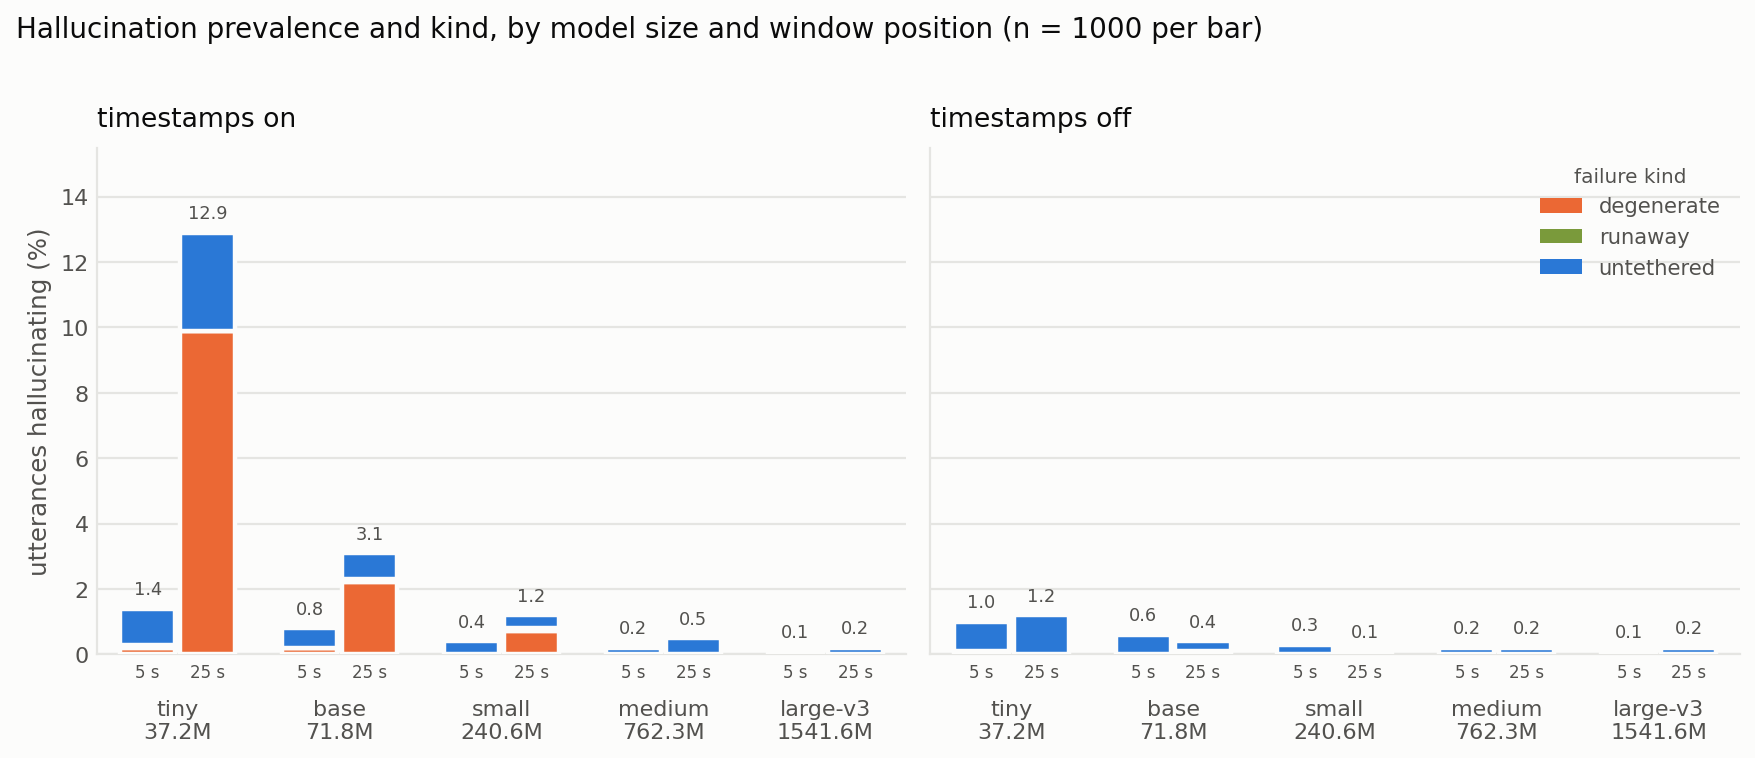

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

mpl.rcParams["pdf.fonttype"] = 42          # TrueType; Type 3 is rejected by arXiv's checker
mpl.rcParams["ps.fonttype"]  = 42

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e5e5e2"
# categorical, fixed order, validated for CVD separation against this surface
CCAT = {"degenerate": "#eb6834", "runaway": "#7a9a3b", "untethered": "#2a78d6"}

TOT = {(m, o, a): sum(100 * SUMMARY[f"{m}|{o}|{a}"][f"n_{c}"] / 1000 for c in HCATS)
       for m in MODELS for o in (5, 25) for a in ("on", "off")}
YTOP = max(TOT.values()) * 1.20 or 1.0            # headroom for the direct-labelled totals

x, w = np.arange(len(MODELS)), 0.34
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), dpi=160, sharey=True)
fig.patch.set_facecolor(SURFACE)

for ax, arm in zip(axes, ("on", "off")):
    ax.set_facecolor(SURFACE)
    ax.grid(True, axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for j, off in enumerate((5, 25)):
        pos, bottom = x + (j - 0.5) * (w + 0.03), np.zeros(len(MODELS))
        for c in HCATS:
            vals = np.array([100 * SUMMARY[f"{m}|{off}|{arm}"][f"n_{c}"] / 1000 for m in MODELS])
            ax.bar(pos, vals, w, bottom=bottom, color=CCAT[c], zorder=3,
                   edgecolor=SURFACE, linewidth=2)     # 2px surface gap between segments
            bottom += vals
        for xi, tot in zip(pos, bottom):
            if tot > 0:
                ax.text(xi, tot + YTOP * 0.02, f"{tot:.1f}", ha="center", va="bottom",
                        fontsize=8, color=INK2, zorder=4)
        # x in data, y in axes fraction: sits just under the spine, above the model label
        for xi in pos:
            ax.text(xi, -0.018, f"{off} s", transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=7.5, color=INK2)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{m}\n{PARAMS[m]}" for m in MODELS])
    ax.set_xlim(-0.5, len(MODELS) - 0.5)
    ax.set_ylim(0, YTOP)
    ax.set_title(f"timestamps {arm}", fontsize=12, color=INK, pad=10, loc="left")
    ax.tick_params(colors=INK2, labelsize=10, length=0)
    ax.tick_params(axis="x", pad=20)                   # clear the 5 s / 25 s sub-labels
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ("left", "bottom"):
        ax.spines[sp].set_color(GRID); ax.spines[sp].set_linewidth(1)

axes[0].set_ylabel("utterances hallucinating (%)", fontsize=11, color=INK2)
# explicit handles: the bars live on axes[0], the legend belongs on the empty off-arm panel
leg = axes[1].legend(handles=[Patch(facecolor=CCAT[c], label=c) for c in HCATS],
                     frameon=False, fontsize=9.5, loc="upper right", title="failure kind")
leg.get_title().set_color(INK2); leg.get_title().set_fontsize(9)
for t in leg.get_texts():
    t.set_color(INK2)
fig.suptitle("Hallucination prevalence and kind, by model size and window position "
             "(n = 1000 per bar)", fontsize=12.5, color=INK, x=0.007, ha="left", y=1.02)
fig.tight_layout()

for ext in ("pdf", "png"):
    fig.savefig(f"halluc_taxonomy.{ext}", bbox_inches="tight", facecolor=SURFACE)
    fig.savefig(os.path.join(DRIVE_ROOT, f"halluc_taxonomy.{ext}"),
                bbox_inches="tight", facecolor=SURFACE)
print("wrote halluc_taxonomy.pdf and .png (+ copies on Drive)")
plt.show()

from google.colab import files
files.download("halluc_taxonomy.pdf")      # vector, to local disk
# files.download("halluc_taxonomy.png")

## 13. Standalone reload

No GPU, no TIMIT, no Drive-only file, and no earlier cell in this notebook. It reads the committed
`halluc_taxonomy.csv` and rebuilds the headline table plus one re-cut of the taxonomy, which proves
both that the write reached Drive rather than sitting in a FUSE buffer and that the git-safe file
alone carries enough to reproduce and revise every number above.

In [14]:
# --- standalone: run this alone in a fresh CPU runtime -------------------------------
import csv, collections, math, os

PATH = "/content/drive/MyDrive/NAACL/halluc_taxonomy.csv"   # or a local download
rows = list(csv.DictReader(open(PATH, newline="")))

MODELS_ = ["tiny", "base", "small", "medium", "large-v3"]
CONDS_  = [(5, "on"), (5, "off"), (25, "on"), (25, "off")]
HCATS_  = ["degenerate", "runaway", "untethered"]
by = collections.defaultdict(list)
for r in rows:
    by[(r["model"], int(r["offset_s"]), r["timestamps"])].append(r)


def wilson_(k, n, z=1.959963985):
    p, d = k / n, 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return p, max(0.0, c - h), min(1.0, c + h)


print(f"reloaded {len(rows)} rows from {os.path.basename(PATH)}\n")
print(f"{'model':>9} " + " ".join(f"{f'{o} s / ts {t}':>21}" for o, t in CONDS_))
print("-" * 96)
for m in MODELS_:
    out = []
    for o, t in CONDS_:
        rs = by[(m, o, t)]
        p, lo, hi = wilson_(sum(int(r["halluc"]) for r in rs), len(rs))
        out.append(f"{100*p:5.1f} [{100*lo:4.1f},{100*hi:4.1f}]")
    print(f"{m:>9} " + " ".join(f"{c:>21}" for c in out))

print(f"\ncomposition at 25 s / ts on")
print(f"{'model':>9} " + " ".join(f"{c:>12}" for c in HCATS_))
for m in MODELS_:
    cnt = collections.Counter(r["category"] for r in by[(m, 25, "on")])
    print(f"{m:>9} " + " ".join(f"{cnt.get(c, 0):>12}" for c in HCATS_))

# re-cutting needs only this file: every raw measurement was kept
strict = {m: 100 * sum(float(r["len_ratio"]) >= 3.0 or int(r["max_run_fuzzy"]) >= 4
                       or float(r["precision"]) < 0.15 for r in by[(m, 25, "on")]) / 1000
          for m in MODELS_}
print("\nstricter definition (ratio >= 3, reps >= 4, precision < 0.15) at 25 s / ts on:")
print("  " + "  ".join(f"{m} {strict[m]:.1f}%" for m in MODELS_))

reloaded 20000 rows from halluc_taxonomy.csv

    model           5 s / ts on          5 s / ts off          25 s / ts on         25 s / ts off
------------------------------------------------------------------------------------------------
     tiny       1.4 [ 0.8, 2.3]       1.0 [ 0.5, 1.8]      12.9 [11.0,15.1]       1.2 [ 0.7, 2.1]
     base       0.8 [ 0.4, 1.6]       0.6 [ 0.3, 1.3]       3.1 [ 2.2, 4.4]       0.4 [ 0.2, 1.0]
    small       0.4 [ 0.2, 1.0]       0.3 [ 0.1, 0.9]       1.2 [ 0.7, 2.1]       0.1 [ 0.0, 0.6]
   medium       0.2 [ 0.1, 0.7]       0.2 [ 0.1, 0.7]       0.5 [ 0.2, 1.2]       0.2 [ 0.1, 0.7]
 large-v3       0.1 [ 0.0, 0.6]       0.1 [ 0.0, 0.6]       0.2 [ 0.1, 0.7]       0.2 [ 0.1, 0.7]

composition at 25 s / ts on
    model   degenerate      runaway   untethered
     tiny           99            0           30
     base           22            1            8
    small            7            1            4
   medium            0            0         